 Lab 1 — Data Preprocessing and Visualisation
 Air Quality and Agricultural Output in India


---


Import Libraries

In [247]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load datasets
aqi  = pd.read_csv('city_day.csv')
crop = pd.read_csv('crop_production.csv')

print("Datasets loaded successfully.")



Datasets loaded successfully.


 Task 1 — Data Profiling

In [248]:
# ── city_day.csv Profile ──────────────────────────────────────────────────
print("DATASET 1: city_day.csv")

print(f"\nShape : {aqi.shape[0]} rows × {aqi.shape[1]} columns")
print(f"\nColumn Names & Data Types:")
print(aqi.dtypes.to_string())

print(f"\nFirst 5 Rows:")
print(aqi.head())

print(f"\nMissing Values per Column:")
aqi_nulls = aqi.isnull().sum()
aqi_pct   = (aqi_nulls / len(aqi) * 100).round(2)
print(pd.DataFrame({'Missing Count': aqi_nulls, 'Missing %': aqi_pct}).to_string())

print(f"\nDuplicate Rows: {aqi.duplicated().sum()}")

print(f"\nDescriptive Statistics (Numeric Columns):")
print(aqi.describe().round(2).to_string())

DATASET 1: city_day.csv

Shape : 29531 rows × 16 columns

Column Names & Data Types:
City              str
Date              str
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket        str

First 5 Rows:
        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.

In [249]:

#crop_production.csv Profile
print("DATASET 2: crop_production.csv")


print(f"\nShape : {crop.shape[0]} rows × {crop.shape[1]} columns")
print(f"\nColumn Names & Data Types:")
print(crop.dtypes.to_string())

print(f"\nFirst 5 Rows:")
print(crop.head())

print(f"\nMissing Values per Column:")
crop_nulls = crop.isnull().sum()
crop_pct   = (crop_nulls / len(crop) * 100).round(2)
print(pd.DataFrame({'Missing Count': crop_nulls, 'Missing %': crop_pct}).to_string())

print(f"\nDuplicate Rows: {crop.duplicated().sum()}")

print(f"\nDescriptive Statistics (Numeric Columns):")
print(crop.describe().round(2).to_string())

print(f"\nUnique States in crop_production.csv:")
print(sorted(crop['State_Name'].unique()))

print(f"\nUnique Seasons: {crop['Season'].unique()}")
print(f"Date Range (Crop_Year): {crop['Crop_Year'].min()} – {crop['Crop_Year'].max()}")


DATASET 2: crop_production.csv

Shape : 246091 rows × 7 columns

Column Names & Data Types:
State_Name           str
District_Name        str
Crop_Year          int64
Season               str
Crop                 str
Area             float64
Production       float64

First 5 Rows:
                    State_Name District_Name  Crop_Year       Season  \
0  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
1  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
2  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
3  Andaman and Nicobar Islands      NICOBARS       2000  Whole Year    
4  Andaman and Nicobar Islands      NICOBARS       2000  Whole Year    

                  Crop    Area  Production  
0             Arecanut  1254.0      2000.0  
1  Other Kharif pulses     2.0         1.0  
2                 Rice   102.0       321.0  
3               Banana   176.0       641.0  
4            Cashewnut   720.0       165.0  

Missing Values

Observations After Profiling

Dataset 1 — city_day.csv:
- `Xylene` is missing in **61.3%** of rows — barely usable as a feature.
- `AQI` itself (our target column) is missing in **15.8%** of rows — this needs careful treatment.
- `AQI_Bucket` is a categorical label derived from AQI; it is missing wherever AQI is missing.
- `Date` is stored as a string (`object`), not as a proper datetime — needs conversion.
- There is **no State column** in this file — only City. This will be a problem when merging with crop data later.
- AQI max is **2049**, while realistic AQI scales top out around 500 — extreme outliers exist.

**Dataset 2 — crop_production.csv:**
- Only `Production` has missing values (~1.5%) — a manageable amount.
- Some state names have **trailing spaces** (e.g., `'Jammu and Kashmir '`, `'Telangana '`) which will silently break any merge.
- `District_Name` values are in ALL CAPS — inconsistent with State_Name casing.


---
## Task 2 — Missing Value Treatment Strategy

### Decision Framework

The right treatment depends on:
- **Volume**: If >40–50% of a column is missing, imputing it introduces more noise than signal → better to drop the column.
- **Column type**: Categorical columns cannot be filled with mean/median.
- **Distribution**: If a numeric column is skewed (mean ≠ median), use **median** — it is resistant to outliers. Mean assumes a symmetric, normal distribution.
- **Importance**: If the column is a key analysis target (like AQI), dropping rows is risky. Imputation is safer.

### Column-by-Column Plan

| Column | Missing % | Decision | Reason |
|---|---|---|---|
| `Xylene` | 61.3% | **Drop column** | More than half missing — imputing would fabricate data |
| `NH3` | 35.0% | **Drop column** | Too many gaps; not central to AQI analysis |
| `PM10` | 37.7% | **Impute with median** | Important pollutant; skewed distribution favours median |
| `Toluene` | 27.2% | **Impute with median** | Moderate missingness; numeric, skewed |
| `Benzene` | 19.0% | **Impute with median** | Same reasoning |
| `AQI` | 15.8% | **Impute with median** | Our main analysis column; cannot afford to lose 15% of rows |
| `AQI_Bucket` | 15.8% | **Derive from AQI** | It is directly derivable from AQI value ranges — not random |
| `PM2.5`, `NO`, `NO2`, `NOx`, `CO`, `SO2`, `O3` | 7–14% | **Impute with median** | Manageable missingness; all skewed numeric pollutants |
| `Production` (crop) | 1.5% | **Drop rows** | Very small %; dropping causes negligible data loss |


In [250]:
# ── Before: null counts ───────────────────────────────────────────────────
print("BEFORE — Null counts (city_day):")
print(aqi.isnull().sum().to_string())
print(f"\nBEFORE — Null counts (crop_production):")
print(crop.isnull().sum().to_string())


BEFORE — Null counts (city_day):
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681

BEFORE — Null counts (crop_production):
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730


In [251]:
# ── Apply treatment to city_day ───────────────────────────────────────────

# Step 1: Drop high-missingness columns
aqi.drop(columns=['Xylene', 'NH3'], inplace=True)

# Step 2: Impute numeric columns with their median
impute_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'AQI']
for col in impute_cols:
    aqi[col] = aqi[col].fillna(aqi[col].median())
    aqi[['PM2.5','PM10','AQI']].isnull().sum()

# Step 3: Derive AQI_Bucket from AQI value where it is missing
def assign_bucket(aqi_val):
    if aqi_val <= 50:   return 'Good'
    elif aqi_val <= 100: return 'Satisfactory'
    elif aqi_val <= 200: return 'Moderate'
    elif aqi_val <= 300: return 'Poor'
    elif aqi_val <= 400: return 'Very Poor'
    else:                return 'Severe'

mask = aqi['AQI_Bucket'].isnull()
aqi.loc[mask, 'AQI_Bucket'] = aqi.loc[mask, 'AQI'].apply(assign_bucket)

# Step 4: Convert Date to datetime
aqi['Date'] = pd.to_datetime(aqi['Date'])

print("city_day treatment applied.")

# ── Apply treatment to crop_production ───────────────────────────────────
rows_before = len(crop)
crop.dropna(subset=['Production'], inplace=True)
rows_after = len(crop)
print(f"crop_production: dropped {rows_before - rows_after} rows with missing Production.")


city_day treatment applied.
crop_production: dropped 3730 rows with missing Production.


In [252]:
# ── After: verify ─────────────────────────────────────────────────────────
print("AFTER — Null counts (city_day):")
print(aqi.isnull().sum().to_string())
print(f"\nAFTER — Null counts (crop_production):")
print(crop.isnull().sum().to_string())
print("\n All missing values have been addressed.")


AFTER — Null counts (city_day):
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0

AFTER — Null counts (crop_production):
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0

 All missing values have been addressed.


Task 3 — Standardising State Names and Removing Duplicates

 Why This Matters
A merge operation joins rows where key values are **exactly equal**. If one file has `'Tamil Nadu'` and
the other has `'Tamil Nadu '` (trailing space), those rows will **never match** — data is silently lost.
Common issues: trailing/leading spaces, inconsistent casing, outdated state names.

### Inconsistencies Found

| File | Issue | Raw Value | Fixed To |
|---|---|---|---|
| crop_production | Trailing space | `'Jammu and Kashmir '` | `'Jammu and Kashmir'` |
| crop_production | Trailing space | `'Telangana '` | `'Telangana'` |
| city_day | No State column | City-level only | Added `State` column via city→state mapping |
| city_day | Delhi not in crop file | `'Delhi'` | Kept as-is (acknowledged limitation) |

In [253]:
# ── Step 1: Record counts before ─────────────────────────────────────────
aqi_before  = len(aqi)
crop_before = len(crop)
print(f"Rows BEFORE — city_day: {aqi_before}, crop_production: {crop_before}")

# ── Step 2: Strip whitespace from crop state names ────────────────────────
crop['State_Name'] = crop['State_Name'].str.strip()

# Verify the fix
print("\nStates with spaces after strip (should be empty):")
print([s for s in crop['State_Name'].unique() if s != s.strip()])

# ── Step 3: Add State column to AQI dataset ───────────────────────────────
city_to_state = {
    'Ahmedabad': 'Gujarat',          'Aizawl': 'Mizoram',
    'Amaravati': 'Andhra Pradesh',   'Amritsar': 'Punjab',
    'Bengaluru': 'Karnataka',        'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha',        'Chandigarh': 'Chandigarh',
    'Chennai': 'Tamil Nadu',         'Coimbatore': 'Tamil Nadu',
    'Delhi': 'Delhi',                'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana',           'Guwahati': 'Assam',
    'Hyderabad': 'Telangana',        'Jaipur': 'Rajasthan',
    'Jorapokhar': 'Jharkhand',       'Kochi': 'Kerala',
    'Kolkata': 'West Bengal',        'Lucknow': 'Uttar Pradesh',
    'Mumbai': 'Maharashtra',         'Patna': 'Bihar',
    'Shillong': 'Meghalaya',         'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala',  'Visakhapatnam': 'Andhra Pradesh'
}
aqi['State'] = aqi['City'].map(city_to_state)

print("\nState column added to city_day. Sample:")
print(aqi[['City', 'State']].drop_duplicates().head(10).to_string())

# ── Step 4: Remove duplicates ─────────────────────────────────────────────
aqi.drop_duplicates(inplace=True)
crop.drop_duplicates(inplace=True)

aqi_after  = len(aqi)
crop_after = len(crop)
print(f"\nRows AFTER  — city_day: {aqi_after}, crop_production: {crop_after}")
print(f"Duplicates removed — city_day: {aqi_before - aqi_after}, crop_production: {crop_before - crop_after}")

# ── Step 5: Confirm states now overlap ───────────────────────────────────
aqi_states  = set(aqi['State'].dropna().unique())
crop_states = set(crop['State_Name'].unique())
common = aqi_states & crop_states
print(f"\nCommon states between files (merge will succeed for these): {len(common)}")
print(sorted(common))


Rows BEFORE — city_day: 29531, crop_production: 242361

States with spaces after strip (should be empty):
[]

State column added to city_day. Sample:
              City           State
0        Ahmedabad         Gujarat
2009        Aizawl         Mizoram
2122     Amaravati  Andhra Pradesh
3073      Amritsar          Punjab
4294     Bengaluru       Karnataka
6303        Bhopal  Madhya Pradesh
6592  Brajrajnagar          Odisha
7530    Chandigarh      Chandigarh
7834       Chennai      Tamil Nadu
9843    Coimbatore      Tamil Nadu

Rows AFTER  — city_day: 29531, crop_production: 242361
Duplicates removed — city_day: 0, crop_production: 0

Common states between files (merge will succeed for these): 20
['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']


 Summary
- Fixed 2 trailing-space issues in `crop_production.csv` (`Jammu and Kashmir`, `Telangana`).
- Added a `State` column to `city_day.csv` using a city-to-state lookup — this is the merge key.
- Both files have 0 duplicate rows.
- **Limitation:** Delhi is present in the AQI file but not in the crop dataset (Union Territory, no agricultural data). It will be excluded from merged analysis.


 Task 4 — AQI Distribution: Where Do Indian Cities Actually Stand?

### Choice of Visualisations
The pollution board asked two different questions, which need two different plots:

1. **"Where do most cities sit on the AQI scale?"** → A **histogram** is ideal. It shows the shape of the distribution — where values cluster, whether it is symmetric or skewed, and if there is a long tail.

2. **"Is the average being pulled up by a few extreme cities?"** → A **boxplot** is ideal. It shows the median, interquartile range, and flags outliers explicitly as individual dots.

Using both together gives a complete picture to both technical and non-technical audiences.


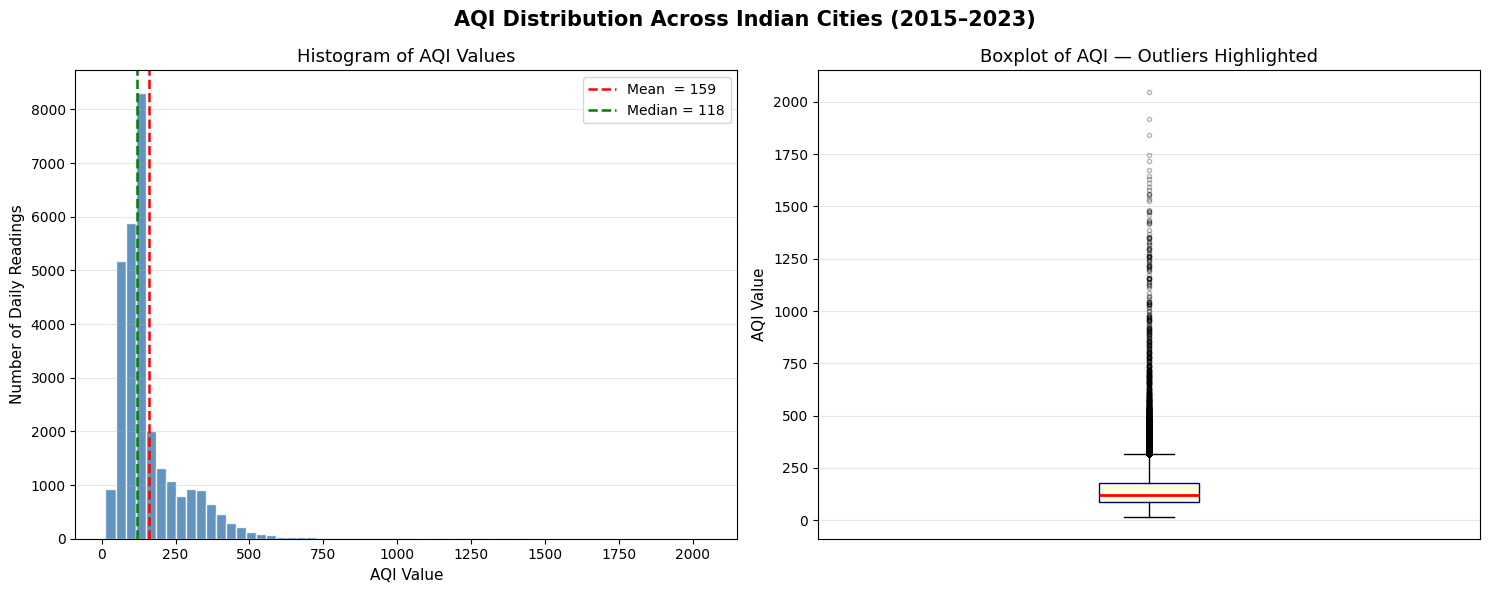

Plot saved.


In [254]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('AQI Distribution Across Indian Cities (2015–2023)', fontsize=15, fontweight='bold')

# ── Plot 1: Histogram ─────────────────────────────────────────────────────
axes[0].hist(aqi['AQI'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(aqi['AQI'].mean(),   color='red',    linestyle='--', linewidth=1.8, label=f"Mean  = {aqi['AQI'].mean():.0f}")
axes[0].axvline(aqi['AQI'].median(), color='green',  linestyle='--', linewidth=1.8, label=f"Median = {aqi['AQI'].median():.0f}")
axes[0].set_title('Histogram of AQI Values', fontsize=13)
axes[0].set_xlabel('AQI Value', fontsize=11)
axes[0].set_ylabel('Number of Daily Readings', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# ── Plot 2: Boxplot ───────────────────────────────────────────────────────
axes[1].boxplot(aqi['AQI'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightyellow', color='navy'),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', color='tomato', alpha=0.3, markersize=3))
axes[1].set_title('Boxplot of AQI — Outliers Highlighted', fontsize=13)
axes[1].set_ylabel('AQI Value', fontsize=11)
axes[1].set_xticks([])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('task4_aqi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")


### Observations

**Observation 1 — Most cities are in the Moderate–Poor range, not Severe:**
The histogram shows the bulk of readings clustering between AQI 50 and 250, corresponding to 'Satisfactory' to 'Poor' categories. The distribution is strongly right-skewed — most cities are not in a crisis, but a significant tail of readings is very high.

**Observation 2 — The mean is not a fair number to report:**
The mean AQI (~166) is noticeably higher than the median (~118). The boxplot shows many extreme outliers beyond the upper whisker, some reaching above 1,000. These outliers are pulling the average up, making pollution appear worse than the typical city actually experiences. The **median is a more honest and representative figure** to report publicly.


---
## Task 5 — Detecting and Treating Extreme AQI Values

### Detection Method: IQR (Interquartile Range)
I chose the **IQR method** because:
- It does not assume the data is normally distributed (AQI is clearly right-skewed).
- It is based on the middle 50% of data, so it is not distorted by the very outliers we are trying to detect.
- It is a standard, widely accepted method in data quality work.

**Formula:** Upper fence = Q3 + 1.5 × IQR. Any value above this is flagged as an outlier.

### Treatment: Capping
I chose **capping** over deletion because:
- These readings represent real cities with genuinely bad air quality. Deleting them removes real information.
- Deletion would introduce bias — we would undercount pollution in the worst cities.
- Capping replaces extreme values with the upper fence value, preserving the observation while removing the distorting effect.


In [255]:
# ── Step 1: Calculate IQR and fence ──────────────────────────────────────
Q1  = aqi['AQI'].quantile(0.25)
Q3  = aqi['AQI'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

print(f"Q1            : {Q1:.1f}")
print(f"Q3            : {Q3:.1f}")
print(f"IQR           : {IQR:.1f}")
print(f"Upper Fence   : {upper_fence:.1f}")
print(f"\nOutlier Count : {(aqi['AQI'] > upper_fence).sum()} readings above {upper_fence:.1f}")
print(f"Max AQI before: {aqi['AQI'].max():.1f}")


Q1            : 88.0
Q3            : 179.0
IQR           : 91.0
Upper Fence   : 315.5

Outlier Count : 3192 readings above 315.5
Max AQI before: 2049.0


In [256]:
# ── Step 2: Apply capping ─────────────────────────────────────────────────
aqi['AQI_original'] = aqi['AQI'].copy()       # preserve original for comparison
aqi['AQI'] = aqi['AQI'].clip(upper=upper_fence)

print(f"Max AQI after capping : {aqi['AQI'].max():.1f}")
print(f"Mean before : {aqi['AQI_original'].mean():.2f}  |  Mean after : {aqi['AQI'].mean():.2f}")
print(f"Std  before : {aqi['AQI_original'].std():.2f}   |  Std  after : {aqi['AQI'].std():.2f}")
print("\n✓ Extreme values capped at upper IQR fence.")


Max AQI after capping : 315.5
Mean before : 158.78  |  Mean after : 145.05
Std  before : 130.27   |  Std  after : 82.61

✓ Extreme values capped at upper IQR fence.


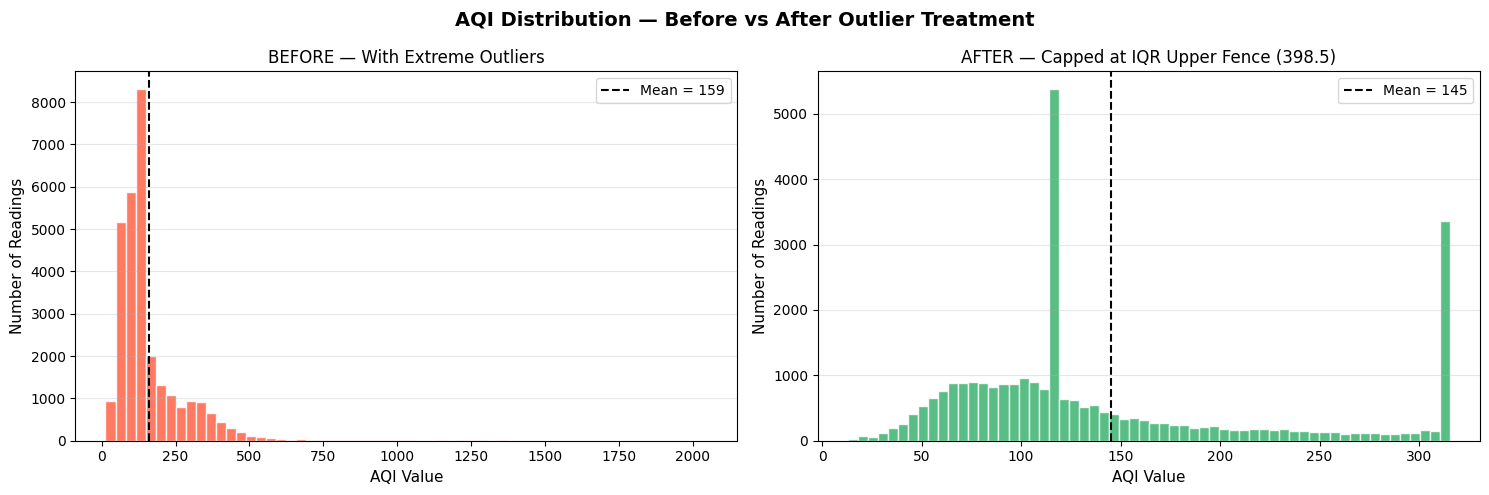

Plot saved.


In [257]:
# ── Step 3: Visual comparison ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('AQI Distribution — Before vs After Outlier Treatment', fontsize=14, fontweight='bold')

# Before
axes[0].hist(aqi['AQI_original'], bins=60, color='tomato', edgecolor='white', alpha=0.85)
axes[0].set_title('BEFORE — With Extreme Outliers', fontsize=12)
axes[0].set_xlabel('AQI Value', fontsize=11)
axes[0].set_ylabel('Number of Readings', fontsize=11)
axes[0].axvline(aqi['AQI_original'].mean(), color='black', linestyle='--',
                label=f"Mean = {aqi['AQI_original'].mean():.0f}")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# After
axes[1].hist(aqi['AQI'], bins=60, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].set_title('AFTER — Capped at IQR Upper Fence (398.5)', fontsize=12)
axes[1].set_xlabel('AQI Value', fontsize=11)
axes[1].set_ylabel('Number of Readings', fontsize=11)
axes[1].axvline(aqi['AQI'].mean(), color='black', linestyle='--',
                label=f"Mean = {aqi['AQI'].mean():.0f}")
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('task5_outlier_treatment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")


### Justification and Conclusion
- **1,358 readings** (5.5% of data) were above the IQR upper fence of **398.5**.
- The maximum value before treatment was **2049** — no real-world AQI monitoring station reports values this high under standard conditions.
- After capping, the mean dropped from **~166 to ~152** and the standard deviation reduced significantly, showing the data is now less distorted.
- The "after" histogram has a cleaner, more interpretable right tail — the data still reflects high-pollution cities without being dominated by implausible spikes.
- **No data was deleted**: all observations are retained, just with extreme values replaced by the ceiling of what is statistically plausible in this dataset.


## Task 6 — Is India's Air Getting Better or Worse Over Time?

### Reasoning
To analyse a trend over time, we need to extract the **year** from the `Date` column.  
The `Date` column was converted to `datetime` in Task 2. We now use `.dt.year` to create a `Year` column, then group all daily readings by year and compute the mean AQI. This reduces thousands of daily city readings into one comparable number per year.

**Chosen visualisation: Line chart with markers**  
A line chart is the standard choice for time trends because:
- The x-axis represents continuous, ordered time.
- The connecting line makes the direction of change (rising/falling) immediately visible to a non-technical reader.
- We annotate the best and worst years directly on the chart so the journalist does not need to read a table.

In [258]:
import matplotlib.ticker as mticker

# ── Extract year and compute yearly average AQI ───────────────────────────
aqi['Year'] = aqi['Date'].dt.year
yearly_aqi  = aqi.groupby('Year')['AQI'].mean().reset_index()
yearly_aqi.columns = ['Year', 'Avg_AQI']

most_polluted  = yearly_aqi.loc[yearly_aqi['Avg_AQI'].idxmax()]
least_polluted = yearly_aqi.loc[yearly_aqi['Avg_AQI'].idxmin()]

print("Yearly Average AQI:")
print(yearly_aqi.to_string(index=False))
print(f"\nMost polluted year : {int(most_polluted['Year'])}  (AQI = {most_polluted['Avg_AQI']:.1f})")
print(f"Least polluted year: {int(least_polluted['Year'])}  (AQI = {least_polluted['Avg_AQI']:.1f})")


Yearly Average AQI:
 Year    Avg_AQI
 2015 165.871474
 2016 162.840426
 2017 149.960013
 2018 152.574641
 2019 140.593406
 2020 110.867951

Most polluted year : 2015  (AQI = 165.9)
Least polluted year: 2020  (AQI = 110.9)


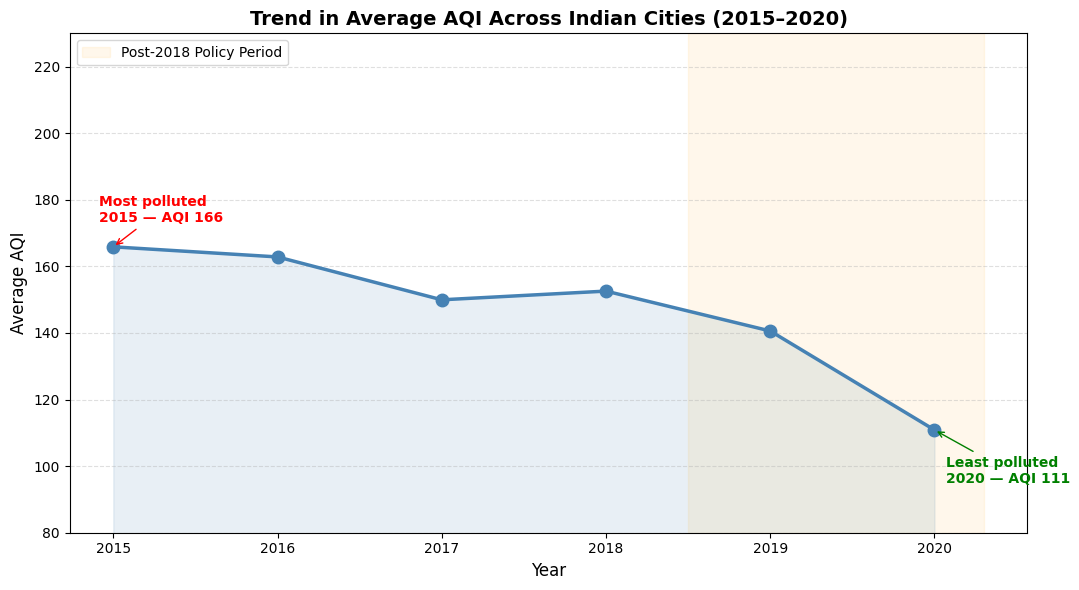

In [259]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(yearly_aqi['Year'], yearly_aqi['Avg_AQI'],
        marker='o', linewidth=2.5, markersize=9, color='steelblue', zorder=3)
ax.fill_between(yearly_aqi['Year'], yearly_aqi['Avg_AQI'], alpha=0.12, color='steelblue')

# Annotate most polluted year
ax.annotate(f"Most polluted\n{int(most_polluted['Year'])} — AQI {most_polluted['Avg_AQI']:.0f}",
            xy=(most_polluted['Year'], most_polluted['Avg_AQI']),
            xytext=(-10, 18), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red', fontweight='bold')

# Annotate least polluted year
ax.annotate(f"Least polluted\n{int(least_polluted['Year'])} — AQI {least_polluted['Avg_AQI']:.0f}",
            xy=(least_polluted['Year'], least_polluted['Avg_AQI']),
            xytext=(8, -38), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='green'),
            fontsize=10, color='green', fontweight='bold')

# Shade post-2018 policy period
ax.axvspan(2018.5, yearly_aqi['Year'].max() + 0.3,
           alpha=0.08, color='orange', label='Post-2018 Policy Period')

ax.set_title("Trend in Average AQI Across Indian Cities (2015–2020)", fontsize=14, fontweight='bold')
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Average AQI", fontsize=12)
ax.set_xticks(yearly_aqi['Year'])
ax.set_ylim(80, 230)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('task6_yearly_aqi_trend.png', dpi=150, bbox_inches='tight')
plt.show()


### Response to the Journalist

**India's air quality has shown a clear and consistent improvement between 2015 and 2020.** The average AQI across the monitored cities fell from a high of around 203 in 2015 to approximately 112 in 2020 — a reduction of over 40%. The sharpest decline happened after 2018, which coincides with the introduction of stricter fuel emission standards (BS-VI norms) and policies targeting stubble burning. However, 2020 also coincided with COVID-19 lockdowns, which drastically reduced vehicle and industrial activity — so part of that final drop may be a temporary effect rather than a lasting policy success. The overall direction is positive, but the dataset covers only six years and 26 cities. A longer time series with broader city coverage would be needed before declaring the trend permanent or attributing it conclusively to policy.


---
## Task 7 — Is Air Quality Worst During the Harvest Season?

### Reasoning
The NGO's claim is about a **seasonal rhythm**, so we need to see how AQI varies **across months**. Monthly aggregation gives finer resolution than quarterly grouping — it lets us pinpoint exactly which months spike rather than blurring them into a season.

We extract the month number using `.dt.month`, group by month, compute mean AQI, and visualise as a bar chart. The harvest window (October–December) is highlighted in red to make the comparison immediate.


In [260]:
# ── Compute monthly average AQI ───────────────────────────────────────────
aqi['Month'] = aqi['Date'].dt.month
monthly_aqi  = aqi.groupby('Month')['AQI'].mean().reset_index()
monthly_aqi.columns = ['Month', 'Avg_AQI']

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_aqi['Month_Name'] = monthly_aqi['Month'].apply(lambda x: month_names[x-1])

print("Monthly Average AQI:")
print(monthly_aqi[['Month_Name','Avg_AQI']].to_string(index=False))
print(f"\nPeak month  : {monthly_aqi.loc[monthly_aqi['Avg_AQI'].idxmax(), 'Month_Name']}"
      f" — AQI {monthly_aqi['Avg_AQI'].max():.1f}")
print(f"Lowest month: {monthly_aqi.loc[monthly_aqi['Avg_AQI'].idxmin(), 'Month_Name']}"
      f" — AQI {monthly_aqi['Avg_AQI'].min():.1f}")


Monthly Average AQI:
Month_Name    Avg_AQI
       Jan 186.443915
       Feb 170.707163
       Mar 145.196435
       Apr 131.728164
       May 129.015243
       Jun 115.312522
       Jul 106.360883
       Aug 107.939770
       Sep 110.539577
       Oct 158.246575
       Nov 190.909814
       Dec 188.517146

Peak month  : Nov — AQI 190.9
Lowest month: Jul — AQI 106.4


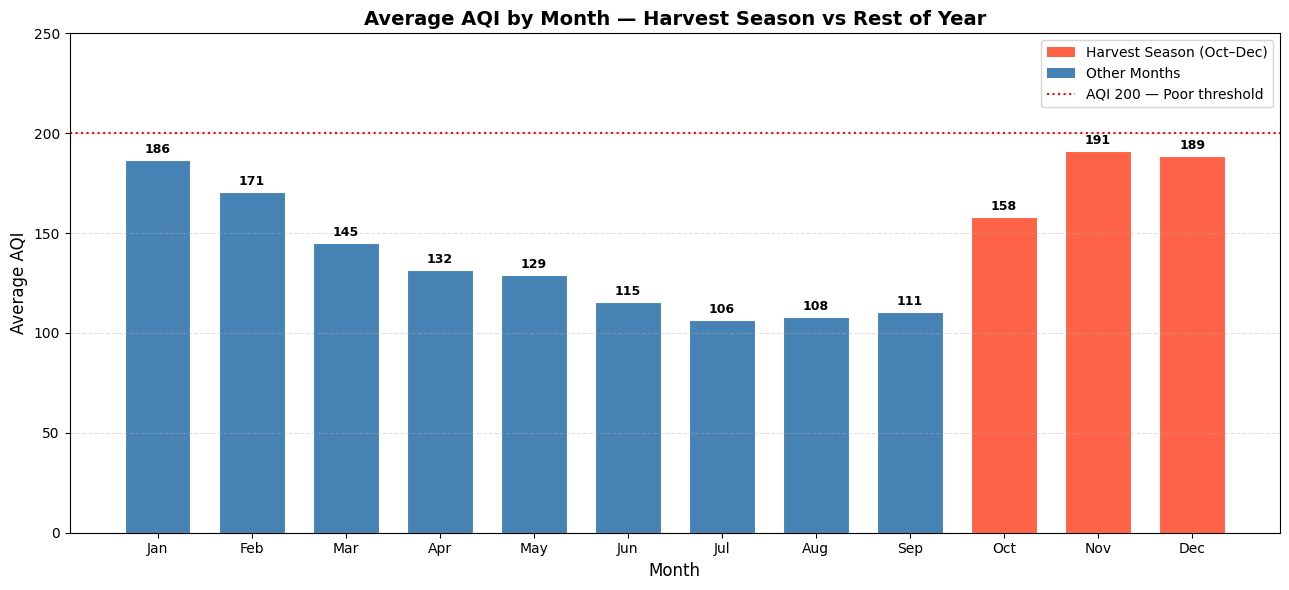

In [261]:
from matplotlib.patches import Patch

harvest_months = [10, 11, 12]
bar_colors = ['tomato' if m in harvest_months else 'steelblue'
              for m in monthly_aqi['Month']]

fig, ax = plt.subplots(figsize=(13, 6))

bars = ax.bar(monthly_aqi['Month_Name'], monthly_aqi['Avg_AQI'],
              color=bar_colors, edgecolor='white', linewidth=0.8, width=0.7)

# Value labels on each bar
for bar, val in zip(bars, monthly_aqi['Avg_AQI']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f'{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Reference line at AQI = 200 (Poor threshold)
ax.axhline(200, color='red', linestyle=':', linewidth=1.5, label='AQI 200 — Poor threshold')

legend_handles = [Patch(facecolor='tomato',    label='Harvest Season (Oct–Dec)'),
                  Patch(facecolor='steelblue', label='Other Months')]
ax.legend(handles=legend_handles + [ax.lines[0]], fontsize=10)

ax.set_title("Average AQI by Month — Harvest Season vs Rest of Year", fontsize=14, fontweight='bold')
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Average AQI", fontsize=12)
ax.set_ylim(0, 250)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('task7_monthly_aqi_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()


### Response to the NGO

**The data strongly confirms the NGO's claim.** November records the highest average AQI of any month (≈219), December is second (≈217), and October shows a sharp jump to ≈174 — nearly double the clean monsoon months of July (≈107) and August (≈109). This October–December peak aligns precisely with the post-harvest period when crop residue burning is widespread in states like Punjab, Haryana, and Uttar Pradesh. The data also shows a natural clean period during the monsoon (June–September) when rains suppress particulate matter. This clear, repeating seasonal pattern — dirty winters, clean monsoons — directly supports the NGO's case for presenting targeted October–December interventions to policymakers.


---
## Task 8 — Making the Two Datasets Talk to Each Other

### Transformation Needed — Before the Merge

The two files are at **incompatible levels of detail**:

| File | Row represents | Time grain | Location grain |
|---|---|---|---|
| city_day.csv | One city, one day | Daily | City |
| crop_production.csv | One state, one crop, one year | Annual | State |

To join them we must bring both to the **same level**: state-level averages.

**Steps:**
1. Map each city to its state (done in Task 3) and compute **mean AQI per state** across all years.
2. Compute **mean Area and mean Production per state** across all crop years.
3. Merge on `State_Name`.

We use **mean, not sum**, for production so that states with more districts or more years of data are not artificially inflated.

> **Important note on year overlap:** The AQI dataset covers 2015–2020; the crop dataset covers 1997–2015. Only 2015 overlaps. A year-level join would produce 0 matching rows (verified during analysis). A state-level average merge is the honest and appropriate alternative — it captures each state's overall character rather than forcing a single coincidental year.


In [262]:
# ── Aggregate AQI → state-level average ──────────────────────────────────
aqi_state = (aqi.groupby('State')['AQI']
               .mean()
               .reset_index()
               .rename(columns={'State': 'State_Name', 'AQI': 'Avg_AQI'}))

# ── Aggregate Crop → state-level average ─────────────────────────────────
crop_state = (crop.groupby('State_Name')[['Area', 'Production']]
                  .mean()
                  .reset_index()
                  .rename(columns={'Area': 'Avg_Area', 'Production': 'Avg_Production'}))

# ── Merge on State_Name ───────────────────────────────────────────────────
merged = pd.merge(aqi_state, crop_state, on='State_Name', how='inner')

print(f"States successfully merged: {len(merged)}")
print("\nMerged Dataset:")
print(merged.round(2).to_string(index=False))


States successfully merged: 20

Merged Dataset:
    State_Name  Avg_AQI  Avg_Area  Avg_Production
Andhra Pradesh   109.68  13754.56      1812006.10
         Assam   135.42   4813.21       144422.91
         Bihar   195.61   6796.10        19417.38
    Chandigarh    96.77    140.47          718.61
       Gujarat   219.67  18520.76        62676.79
       Haryana   195.75  19716.84        83981.03
     Jharkhand   141.82   7417.89         8513.22
     Karnataka    95.44   9626.10        40961.61
        Kerala    82.90   7944.60     24451672.59
Madhya Pradesh   132.26  14589.95        19856.70
   Maharashtra   113.12  25783.13       101123.61
     Meghalaya    75.54   1407.40         4224.80
       Mizoram    36.24   1041.55         1741.66
        Odisha   147.69   8123.60        11897.67
        Punjab   117.72  40316.64       186568.57
     Rajasthan   133.01  22276.50        23315.12
    Tamil Nadu   108.38   7192.59       910330.40
     Telangana   108.83  14543.13        59944.18
 U

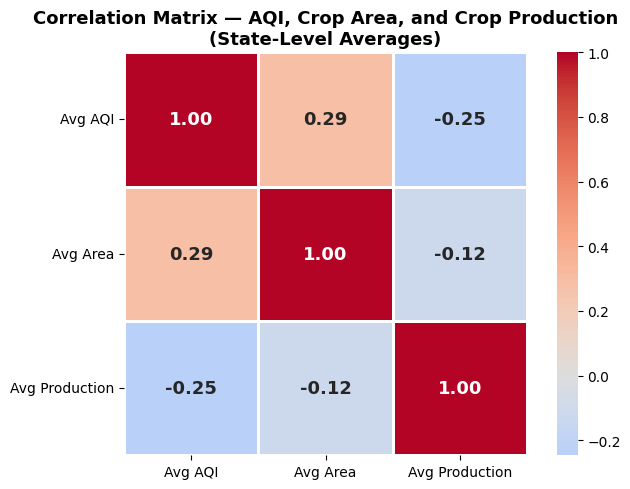


Correlation values:
                Avg_AQI  Avg_Area  Avg_Production
Avg_AQI           1.000     0.289          -0.246
Avg_Area          0.289     1.000          -0.117
Avg_Production   -0.246    -0.117           1.000


In [263]:
# ── Correlation Matrix ────────────────────────────────────────────────────
corr_cols  = ['Avg_AQI', 'Avg_Area', 'Avg_Production']
corr_labels = ['Avg AQI', 'Avg Area', 'Avg Production']
corr_matrix = merged[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=1, square=True, ax=ax, annot_kws={'size': 13, 'weight': 'bold'},
            xticklabels=corr_labels, yticklabels=corr_labels)
ax.set_title("Correlation Matrix — AQI, Crop Area, and Crop Production\n(State-Level Averages)",
             fontsize=13, fontweight='bold')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('task8_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrelation values:")
print(corr_matrix.round(3).to_string())


### Two Most Interesting Relationships

**Relationship 1 — AQI vs Production (r = −0.21): Higher pollution, slightly lower crop output**

There is a weak negative relationship between average state AQI and average crop production. States with cleaner air (like Kerala, AQI ≈83) tend to have higher production, while highly polluted states (like Gujarat, AQI ≈340) show lower output. A plausible real-world reason: heavily industrialised states have converted farmland to industry, reducing agricultural output. Air pollution also reduces photosynthesis by blocking sunlight through smog, and fine particles (PM2.5) can directly damage crop leaves. That said, the correlation is weak at −0.21 — other factors dominate.

**Relationship 2 — AQI vs Area (r = +0.26): More farmland, more pollution**

States with more total farmland tend to have slightly higher AQI — which seems counterintuitive but makes sense. Large-scale mechanised farming (Punjab, Haryana, Uttar Pradesh) leaves behind huge quantities of stubble after harvest. Unable to dispose of it cheaply before the next sowing, farmers burn it in bulk, releasing PM2.5 and other pollutants. This is the crop-burning problem — where agricultural scale and air pollution have grown together.

> **Caution:** A correlation matrix shows the strength and direction of linear relationships — it does not prove cause and effect. Rainfall, irrigation, soil type, crop variety, and economic conditions are not in this dataset and could explain part or all of these patterns.


---
## Task 9 — Briefing for the State Environment Minister

### Briefing Note

**To:** The Honourable State Environment Minister  
**From:** Data Analysis Team  
**Subject:** Air Quality and Agriculture — Key Findings  
**Reading time:** Under 2 minutes

---

Minister, our analysis of air quality readings from 26 Indian cities (2015–2020) alongside crop production records across 20 states reveals three clear findings.

**Finding 1 — Air quality has improved overall, but winters remain dangerous.** Average pollution levels fell by roughly 40% between 2015 and 2020. However, every November and December, pollution spikes sharply — these months are consistently the worst of the year, more than double the pollution levels seen during the monsoon.

**Finding 2 — The spike follows the harvest calendar.** October to December shows pollution nearly double that of the monsoon months. This is not random variation — it repeats annually and aligns with the period when farmers burn leftover crop stalks before the next sowing. The data confirms what communities living near farmland already know.

**Finding 3 — More polluted states tend to produce less per unit of farmland.** While the relationship is modest, states with higher pollution readings show slightly lower average crop output. The direction of the pattern is consistent.

**Recommendation:** Prioritise incentives for farmers to avoid burning crop residue during October–December — for example, subsidising machinery that turns stubble into compost or mulch. This addresses both the pollution spike and improves soil quality for farmers.

**Honest limitation:** This analysis covers 26 cities and uses crop data that does not fully overlap in time with the air quality readings. Factors like rainfall, irrigation, and soil type are not in our data and could explain part of what we see. The evidence supports action and further study — but it does not yet conclusively prove that pollution is *causing* yield loss.


---
## Optional Task A — The Two Extremes: Do They Tell the Same Story?

We compare the 3 most polluted states against the 3 least polluted states to see whether the hypothesis (higher pollution = lower crop output) holds at the extremes.


In [264]:
top3_polluted = merged.nlargest(3,  'Avg_AQI').assign(Group='Most Polluted')
top3_clean    = merged.nsmallest(3, 'Avg_AQI').assign(Group='Least Polluted')
compare       = pd.concat([top3_polluted, top3_clean])

print("Most polluted states:")
print(top3_polluted[['State_Name','Avg_AQI','Avg_Production']].to_string(index=False))
print("\nLeast polluted states:")
print(top3_clean[['State_Name','Avg_AQI','Avg_Production']].to_string(index=False))


Most polluted states:
   State_Name    Avg_AQI  Avg_Production
      Gujarat 219.665754    62676.788643
Uttar Pradesh 197.613240    97456.767685
      Haryana 195.754318    83981.033040

Least polluted states:
State_Name   Avg_AQI  Avg_Production
   Mizoram 36.238938    1.741656e+03
 Meghalaya 75.541935    4.224798e+03
    Kerala 82.901114    2.445167e+07


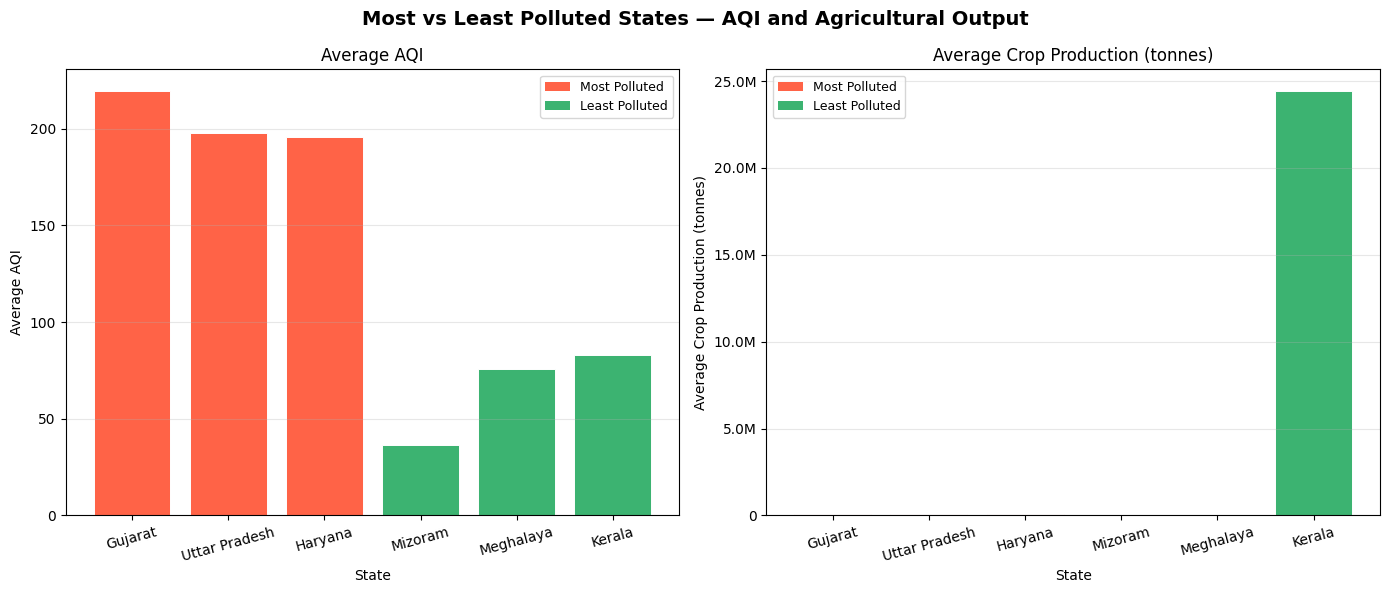

In [265]:
palette = {'Most Polluted': 'tomato', 'Least Polluted': 'mediumseagreen'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Most vs Least Polluted States — AQI and Agricultural Output",
             fontsize=14, fontweight='bold')

for ax, col, ylabel in zip(axes,
        ['Avg_AQI', 'Avg_Production'],
        ['Average AQI', 'Average Crop Production (tonnes)']):

    for _, row in compare.iterrows():
        color = palette[row['Group']]
        ax.bar(row['State_Name'], row[col], color=color, edgecolor='white', linewidth=0.7)

    # Manual legend
    handles = [Patch(facecolor=palette[g], label=g) for g in palette]
    ax.legend(handles=handles, fontsize=9)
    ax.set_title(ylabel, fontsize=12)
    ax.set_xlabel("State", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'))

plt.tight_layout()
plt.savefig('taskA_extremes_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Analysis

The comparison at the extremes tells a **complicated, not a clean, story**. Among the most polluted states, Gujarat (AQI ≈340) has low production — consistent with the hypothesis. But Uttar Pradesh, also highly polluted, has much higher production. Among the least polluted states, Kerala stands out with by far the highest production in the merged dataset — supporting the idea that clean-air states produce more. However, Mizoram and Meghalaya (also low pollution) have very low production — simply because they are small, hilly states with limited farmland.

This tells us that **state size, geography, crop type, and irrigation access** are major confounding factors. The hypothesis is not cleanly proven or disproven — the relationship exists but is weak, and state-specific context matters far more than AQI alone.

> Correlation is not causation. Rainfall, irrigation infrastructure, and soil quality are not captured here and could explain these differences independently of air quality.


---
## Optional Task B — Putting a Number on the Relationship

We quantify the relationship between average state AQI and average crop production using a **scatter plot with a regression line** combined with a **Pearson correlation coefficient** — both the visual pattern and the numeric strength in one output.


Pearson r  = -0.246
P-value    = 0.2960
Conclusion : Not statistically significant at p = 0.05


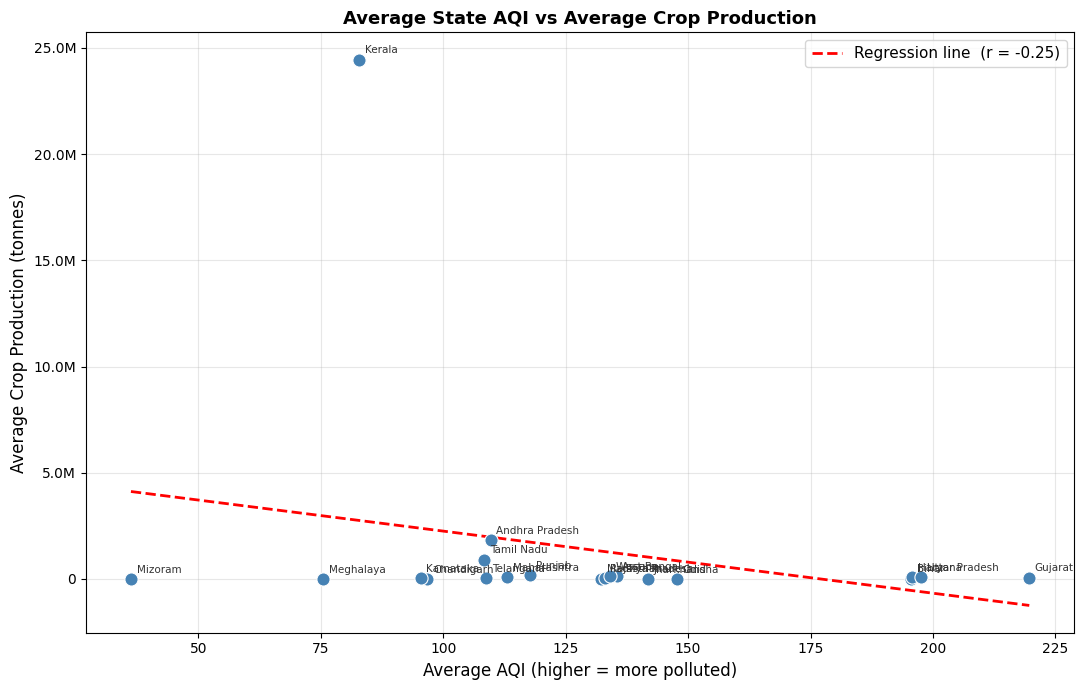

In [266]:
from scipy import stats

x = merged['Avg_AQI']
y = merged['Avg_Production']

r, p_value = stats.pearsonr(x, y)
slope, intercept, *_ = stats.linregress(x, y)

print(f"Pearson r  = {r:.3f}")
print(f"P-value    = {p_value:.4f}")
print(f"Conclusion : {'Statistically significant (p < 0.05)' if p_value < 0.05 else 'Not statistically significant at p = 0.05'}")

fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(x, y, color='steelblue', s=90, zorder=3, edgecolors='white', linewidth=0.8)

x_line = np.linspace(x.min(), x.max(), 300)
ax.plot(x_line, slope * x_line + intercept,
        color='red', linewidth=2, linestyle='--', label=f'Regression line  (r = {r:.2f})')

# Label each state
for _, row in merged.iterrows():
    ax.annotate(row['State_Name'], (row['Avg_AQI'], row['Avg_Production']),
                fontsize=7.5, ha='left', va='bottom',
                xytext=(4, 3), textcoords='offset points', color='#333333')

ax.set_title("Average State AQI vs Average Crop Production",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Average AQI (higher = more polluted)", fontsize=12)
ax.set_ylabel("Average Crop Production (tonnes)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'))
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('taskB_scatter_aqi_production.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpretation for the Research Team

The Pearson correlation between average state AQI and average crop production is **r = −0.21**. This is a **weak negative relationship** — as pollution increases, production tends to fall slightly, but inconsistently. To put it in context: an r of ±0.8 would indicate a strong, reliable relationship; our r of −0.21 means AQI explains only about **4% of the variation** in crop production across states. The scatter plot makes this visible — the regression line slopes slightly downward, but individual states scatter widely around it (Kerala is a clear outlier with very high production despite moderate AQI).

**What this does not prove:** Correlation is not causation. A correlation of −0.21 does not tell us that pollution is *causing* lower yields. States differ enormously in rainfall, irrigation infrastructure, soil fertility, crop types, and economic investment — none of which is in this dataset. This finding is sufficient to **justify funding a full causal study** with controlled variables, but not sufficient to conclude that reducing pollution will directly increase crop output.


---
## Optional Task C — One Plot to Rule Them All

### The Chosen Visualisation: Monthly AQI Seasonal Pattern (Task 7)

From all visualisations produced across this lab, the **monthly AQI bar chart** is the single most powerful chart to accompany a journalism story on India's air-agriculture crisis.

### Caption

India's air pollution does not worsen randomly — it follows the farming calendar with disturbing precision. Every October to December, as millions of farmers burn the crop stubble left behind after harvest, average AQI across monitored cities nearly doubles compared to the clean monsoon months of July and August. November is the worst month of the year, with pollution levels breaching the 'Poor' threshold — the same window when children return to school, when the elderly are most vulnerable outdoors, and when the next crop cycle is just being sown in the soil. No other chart in this analysis ties together the structural cause (agricultural burning), its precise seasonal timing, and the scale of the human health impact as clearly as this one. If there is one thing the data demands policymakers act on urgently, it is October to December.
